# Customer Segmentation Using RFM and K-Means

This notebook develops an end-to-end customer segmentation workflow using Recency, Frequency and Monetary (RFM) behavior, K-Means clustering, validation, SQLite storage, and SQL business analysis.

Workflow:

1. Data loading and cleaning
2. RFM feature engineering
3. Exploratory analysis
4. Feature transformation and scaling
5. K-Means clustering
6. Cluster selection and validation
7. Business profiling and segment naming
8. Cluster stability testing
9. Final segment profile

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)

pd.set_option("display.max_columns", None)

## 1. Data Loading and Cleaning

In [2]:
df = pd.read_csv("hmm.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
print("Shape:", df.shape)
print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (1067371, 8)

Missing values:


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


Duplicate rows: 34335


In [4]:
df = df.dropna(subset=["Customer ID"]).drop_duplicates()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Date range:", df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())
print("Shape after cleaning:", df.shape)

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Shape after cleaning: (797885, 8)


In [5]:
print("Cancellation invoices:", df["Invoice"].astype(str).str.startswith("C").sum())
print("Negative quantities:", (df["Quantity"] < 0).sum())

Cancellation invoices: 18390
Negative quantities: 18390


In [6]:
non_product_codes = [
    "POST", "DOT", "M", "D", "S", "ADJUST",
    "AMAZONFEE", "PADS", "CRUK", "B", "BANK CHARGES"
]

df_sales = df[
    (df["Quantity"] > 0) &
    (df["Price"] > 0) &
    (~df["StockCode"].isin(non_product_codes))
].copy()

df_sales["Revenue"] = df_sales["Quantity"] * df_sales["Price"]

df_sales["Price"].describe()

count    776840.000000
mean          2.950697
std           4.411076
min           0.030000
25%           1.250000
50%           1.950000
75%           3.750000
max         649.500000
Name: Price, dtype: float64

## 2. RFM Feature Engineering

In [7]:
reference_date = df_sales["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df_sales
    .groupby("Customer ID")
    .agg(
        Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,1658.40
3,12349.0,19,3,3678.69
4,12350.0,310,1,294.40


## 3. RFM Exploratory Analysis

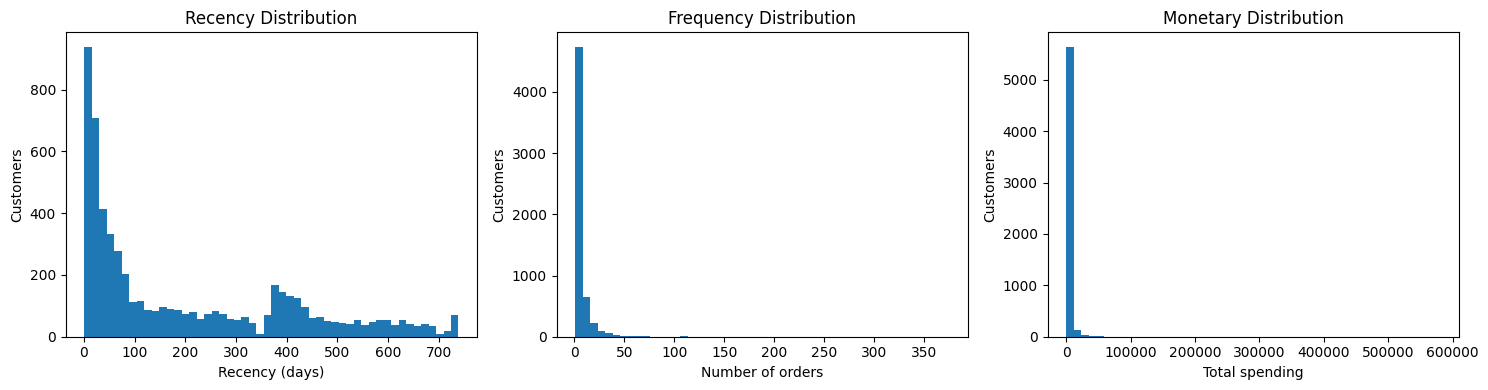

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column, xlabel in zip(
    axes,
    ["Recency", "Frequency", "Monetary"],
    ["Recency (days)", "Number of orders", "Total spending"]
):
    ax.hist(rfm[column], bins=50)
    ax.set_title(f"{column} Distribution")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Customers")

plt.tight_layout()
plt.show()

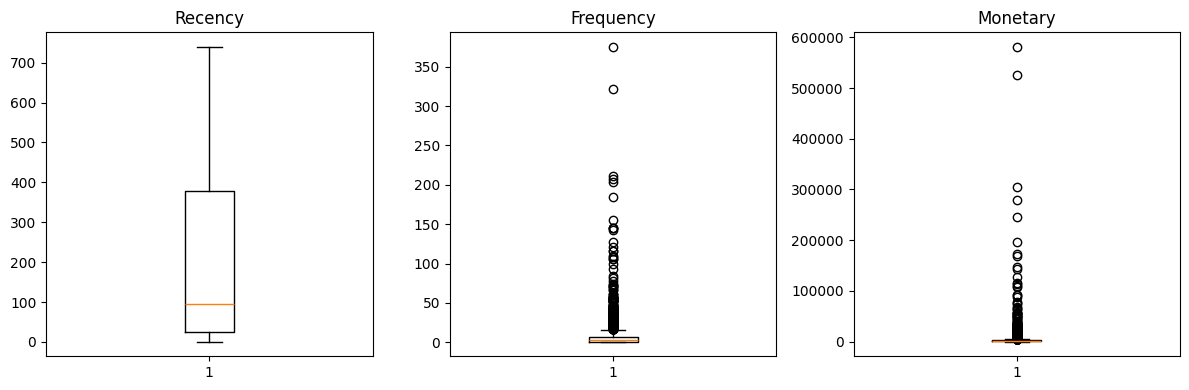

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, column in zip(axes, ["Recency", "Frequency", "Monetary"]):
    ax.boxplot(rfm[column])
    ax.set_title(column)

plt.tight_layout()
plt.show()

In [10]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,5853.000000,5853.000000,5853.000000
mean,200.249103,6.255425,2918.517986
std,208.528333,12.762146,14335.507948
min,1.000000,1.000000,2.950000
25%,25.000000,1.000000,340.850000
50%,95.000000,3.000000,856.030000
75%,379.000000,7.000000,2240.900000
max,739.000000,375.000000,580987.040000


In [11]:
rfm[["Recency", "Frequency", "Monetary"]].skew()

Recency       0.893693
Frequency    12.075434
Monetary     25.294998
dtype: float64

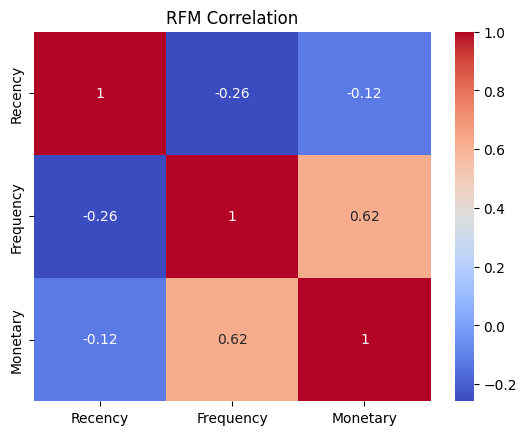

In [12]:
sns.heatmap(
    rfm[["Recency", "Frequency", "Monetary"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("RFM Correlation")
plt.show()

In [13]:
single_order_customers = (rfm["Frequency"] == 1).sum()
single_order_percentage = (rfm["Frequency"] == 1).mean() * 100

print(f"Customers with one order: {single_order_customers:,}")
print(f"Percentage of customers with one order: {single_order_percentage:.2f}%")

Customers with one order: 1,619
Percentage of customers with one order: 27.66%


In [14]:
rfm.sort_values("Monetary", ascending=False).head(10)

,Customer ID,Recency,Frequency,Monetary
5667,18102.0,1,145,580987.04
2263,14646.0,2,145,526751.52
1779,14156.0,10,145,304719.88
2521,14911.0,1,375,279477.79
5027,17450.0,8,51,244784.25
1322,13694.0,4,143,195640.69
5086,17511.0,3,60,172132.87
4038,16446.0,1,2,168472.50
4272,16684.0,4,55,147142.77
67,12415.0,24,24,144033.37


## 4. Feature Transformation and Scaling

In [15]:
features = ["Recency_log", "Frequency_log", "Monetary_log"]

rfm["Recency_log"] = np.log1p(rfm["Recency"])
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])

scaler = StandardScaler()
X = scaler.fit_transform(rfm[features])

X_df = pd.DataFrame(X, columns=features, index=rfm.index)

X_df.describe()

,Recency_log,Frequency_log,Monetary_log
count,5.853000e+03,5.853000e+03,5.853000e+03
mean,2.719316e-16,1.699573e-17,2.136606e-16
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-2.410550e+00,-1.057305e+00,-3.939193e+00
25%,-7.642978e-01,-1.057305e+00,-7.063147e-01
50%,7.408886e-02,-1.992975e-01,-4.019267e-02
75%,9.571283e-01,6.587098e-01,6.567351e-01
max,1.384892e+00,5.424587e+00,4.684487e+00


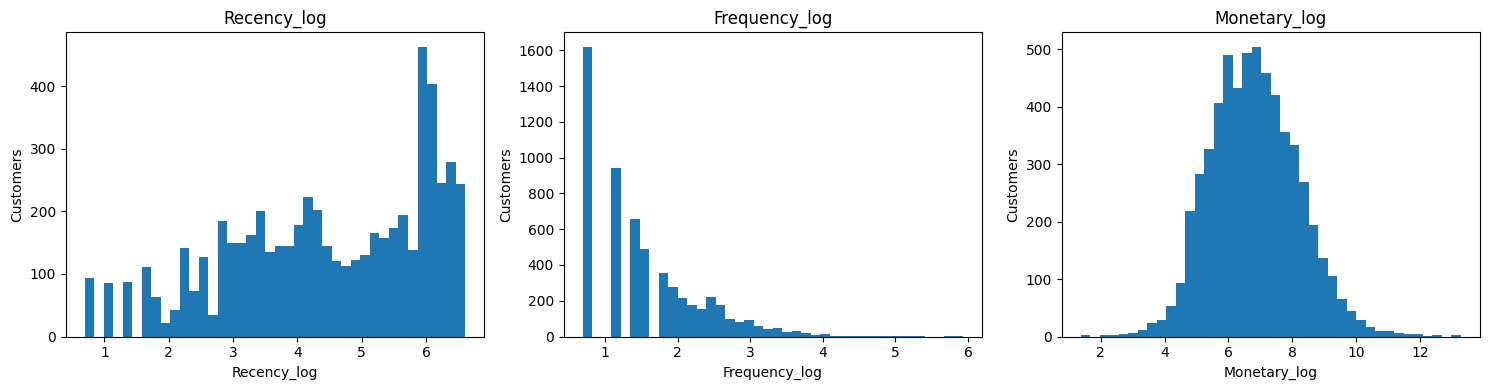

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, features):
    ax.hist(rfm[feature], bins=40)
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Customers")

plt.tight_layout()
plt.show()

## 5. K-Means Model Selection

In [17]:
K_range = range(2, 11)
validation_results = []

for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X)
    cluster_counts = pd.Series(labels).value_counts()

    validation_results.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels),
        "Davies_Bouldin": davies_bouldin_score(X, labels),
        "Min_cluster_size": cluster_counts.min(),
        "Max_cluster_size": cluster_counts.max()
    })

validation_df = pd.DataFrame(validation_results)

validation_df.round(4)

,K,Inertia,Silhouette,Calinski_Harabasz,Davies_Bouldin,Min_cluster_size,Max_cluster_size
0,2,8559.4803,0.4384,6151.8070,0.8736,2312,3541
1,3,6332.6275,0.3482,5185.4662,1.0339,1180,2411
2,4,4904.8790,0.3650,5029.9665,0.9308,1186,1968
3,5,4087.0315,0.3426,4819.2149,0.9501,454,1626
4,6,3545.5745,0.3350,4621.9622,0.9624,465,1469
5,7,3178.3641,0.3027,4408.4715,0.9823,335,1137
6,8,2887.8409,0.2957,4242.1425,0.9913,348,1132
7,9,2646.0055,0.2884,4117.1326,1.0240,257,1088
8,10,2454.5390,0.2896,3995.1327,1.0168,214,1073


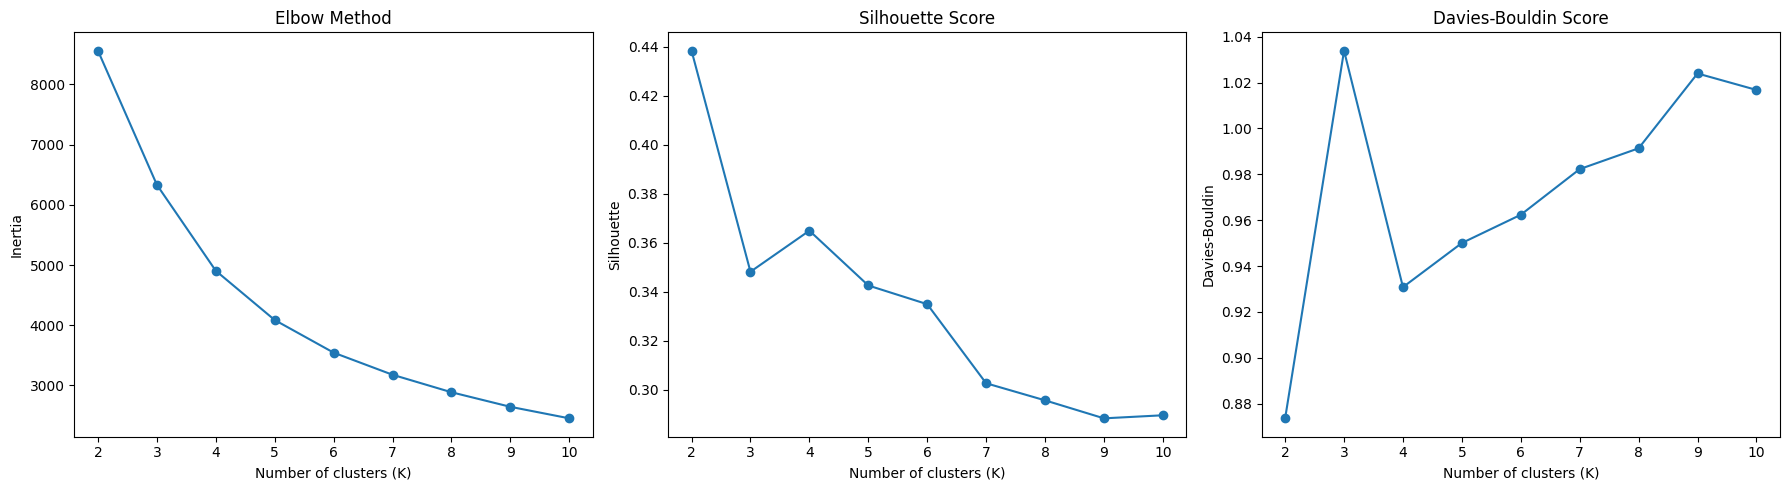

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(validation_df["K"], validation_df["Inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(validation_df["K"], validation_df["Silhouette"], marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette")

axes[2].plot(validation_df["K"], validation_df["Davies_Bouldin"], marker="o")
axes[2].set_title("Davies-Bouldin Score")
axes[2].set_xlabel("Number of clusters (K)")
axes[2].set_ylabel("Davies-Bouldin")

plt.tight_layout()
plt.show()

### Model-selection decision

K=2 produces the strongest purely geometric scores, but it is too coarse for the business objective. K=4 provides a more useful balance between cluster separation, stability and behavioral interpretability.

The final model therefore uses **K=4**.

## 6. Final K-Means Model

In [19]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

rfm["Cluster"] = kmeans.fit_predict(X)

rfm["Cluster"].value_counts().sort_index()

Cluster
0    1968
1    1451
2    1248
3    1186
Name: count, dtype: int64

## 7. Cluster Profiles

In [20]:
cluster_profile = (
    rfm.groupby("Cluster")
    .agg(
        Customers=("Customer ID", "count"),
        Recency_Median=("Recency", "median"),
        Frequency_Median=("Frequency", "median"),
        Monetary_Median=("Monetary", "median"),
        Recency_Mean=("Recency", "mean"),
        Frequency_Mean=("Frequency", "mean"),
        Monetary_Mean=("Monetary", "mean")
    )
)

cluster_profile["Customer_%"] = (
    cluster_profile["Customers"] / len(rfm) * 100
)

revenue_by_cluster = rfm.groupby("Cluster")["Monetary"].sum()

cluster_profile["Revenue_%"] = (
    revenue_by_cluster / rfm["Monetary"].sum() * 100
)

cluster_profile.round(2)

,Customers,Recency_Median,Frequency_Median,Monetary_Median,Recency_Mean,Frequency_Mean,Monetary_Mean,Customer_%,Revenue_%
Cluster,,,,,,,,,
0,1968,401.0,1.0,276.64,392.95,1.38,317.38,33.62,3.66
1,1451,184.0,4.0,1453.68,227.58,5.08,1920.62,24.79,16.31
2,1248,24.0,3.0,719.30,28.27,3.03,841.09,21.32,6.14
3,1186,17.0,13.0,4907.59,28.02,19.19,10641.65,20.26,73.88


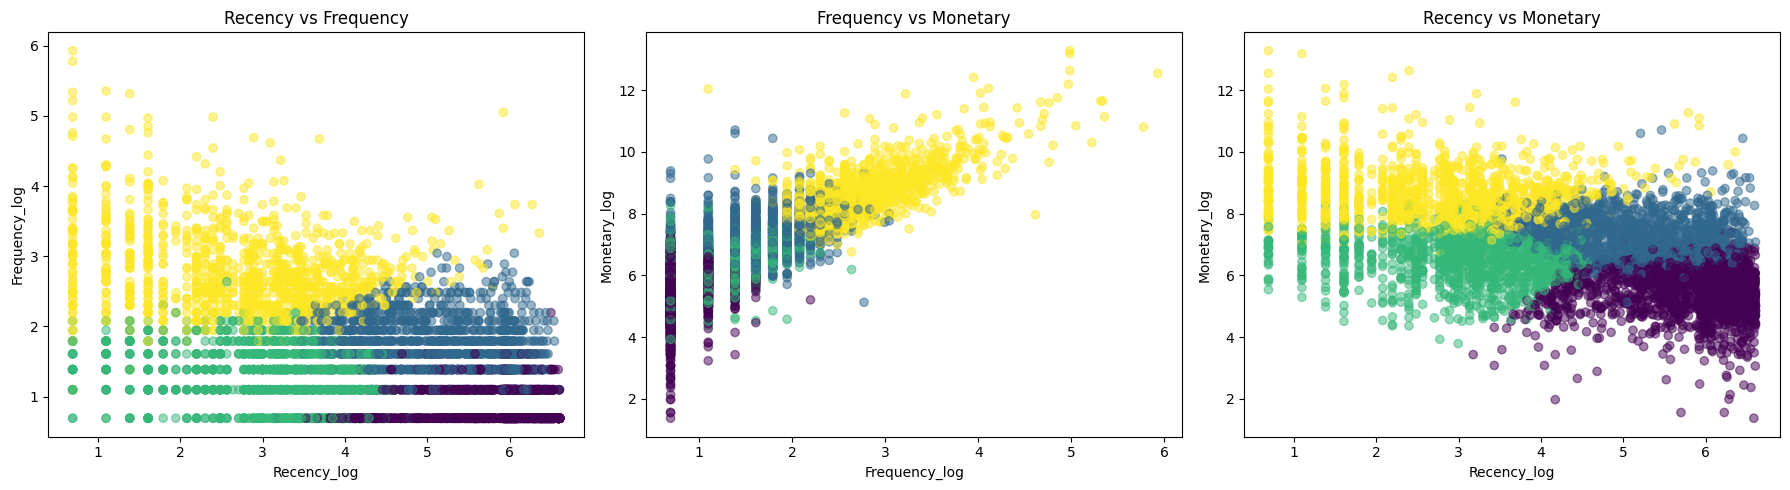

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plots = [
    ("Recency_log", "Frequency_log", "Recency vs Frequency"),
    ("Frequency_log", "Monetary_log", "Frequency vs Monetary"),
    ("Recency_log", "Monetary_log", "Recency vs Monetary")
]

for ax, (x_col, y_col, title) in zip(axes, plots):
    scatter = ax.scatter(
        rfm[x_col],
        rfm[y_col],
        c=rfm["Cluster"],
        alpha=0.5
    )
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)

plt.tight_layout()
plt.show()

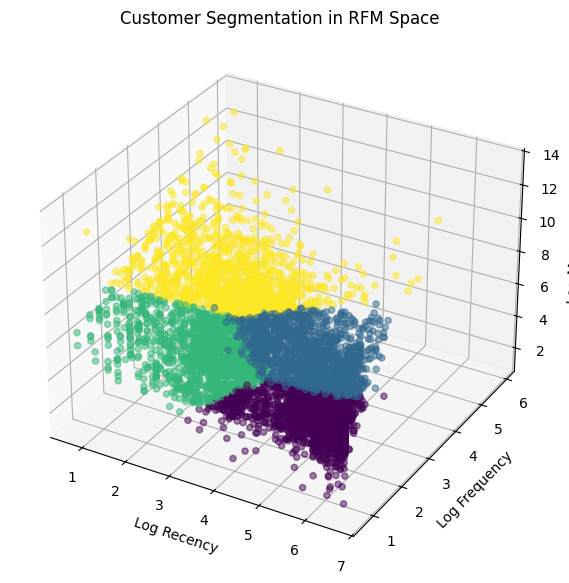

In [22]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    rfm["Recency_log"],
    rfm["Frequency_log"],
    rfm["Monetary_log"],
    c=rfm["Cluster"],
    alpha=0.5
)

ax.set_xlabel("Log Recency")
ax.set_ylabel("Log Frequency")
ax.set_zlabel("Log Monetary")
ax.set_title("Customer Segmentation in RFM Space")

plt.show()

## 8. Business Segment Naming

In [23]:
cluster_names = {
    0: "Inactive / Low-Value",
    1: "At-Risk / Mid-Value",
    2: "Recent / Emerging",
    3: "Champions / High-Value"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

rfm[["Customer ID", "Cluster", "Segment"]].head(10)

,Customer ID,Cluster,Segment
0,12346.0,3,Champions / High-Value
1,12347.0,3,Champions / High-Value
2,12348.0,1,At-Risk / Mid-Value
3,12349.0,2,Recent / Emerging
4,12350.0,0,Inactive / Low-Value
5,12351.0,0,Inactive / Low-Value
6,12352.0,3,Champions / High-Value
7,12353.0,0,Inactive / Low-Value
8,12354.0,0,Inactive / Low-Value
9,12355.0,1,At-Risk / Mid-Value


In [24]:
final_profile = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Recency_Median=("Recency", "median"),
        Frequency_Median=("Frequency", "median"),
        Monetary_Median=("Monetary", "median"),
        Revenue=("Monetary", "sum")
    )
)

final_profile["Customer_%"] = (
    final_profile["Customers"] / len(rfm) * 100
)

final_profile["Revenue_%"] = (
    final_profile["Revenue"] / rfm["Monetary"].sum() * 100
)

final_profile.round(2)

,Customers,Recency_Median,Frequency_Median,Monetary_Median,Revenue,Customer_%,Revenue_%
Segment,,,,,,,
At-Risk / Mid-Value,1451,184.0,4.0,1453.68,2786814.50,24.79,16.31
Champions / High-Value,1186,17.0,13.0,4907.59,12620992.65,20.26,73.88
Inactive / Low-Value,1968,401.0,1.0,276.64,624597.23,33.62,3.66
Recent / Emerging,1248,24.0,3.0,719.30,1049681.39,21.32,6.14


## 9. Final Model Validation

In [25]:
labels = rfm["Cluster"]

silhouette = silhouette_score(X, labels)
calinski = calinski_harabasz_score(X, labels)
davies = davies_bouldin_score(X, labels)

print(f"Silhouette Score:       {silhouette:.4f}")
print(f"Calinski-Harabasz:      {calinski:.4f}")
print(f"Davies-Bouldin:         {davies:.4f}")

Silhouette Score:       0.3650
Calinski-Harabasz:      5029.9665
Davies-Bouldin:         0.9308


## 10. Cluster Stability Validation

In [26]:
baseline_model = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

baseline_labels = baseline_model.fit_predict(X)

stability_scores = []
rng = np.random.default_rng(42)

for run in range(20):
    sample_indices = rng.choice(
        len(X),
        size=int(0.8 * len(X)),
        replace=False
    )

    model = KMeans(
        n_clusters=optimal_k,
        random_state=run,
        n_init=20
    )

    model.fit(X[sample_indices])
    resampled_labels = model.predict(X)

    stability_scores.append(
        adjusted_rand_score(
            baseline_labels,
            resampled_labels
        )
    )

stability_df = pd.DataFrame({
    "Run": range(1, 21),
    "ARI": stability_scores
})

display(stability_df.round(4))

print(f"Mean ARI: {stability_df['ARI'].mean():.4f}")
print(f"Std ARI:  {stability_df['ARI'].std():.4f}")
print(f"Min ARI:  {stability_df['ARI'].min():.4f}")
print(f"Max ARI:  {stability_df['ARI'].max():.4f}")

,Run,ARI
0,1,0.9027
1,2,0.9859
2,3,0.9110
3,4,0.9867
4,5,0.9940
5,6,0.9191
6,7,0.9863
7,8,0.9828
8,9,0.9684
9,10,0.9955


Mean ARI: 0.9708
Std ARI:  0.0297
Min ARI:  0.9027
Max ARI:  0.9956


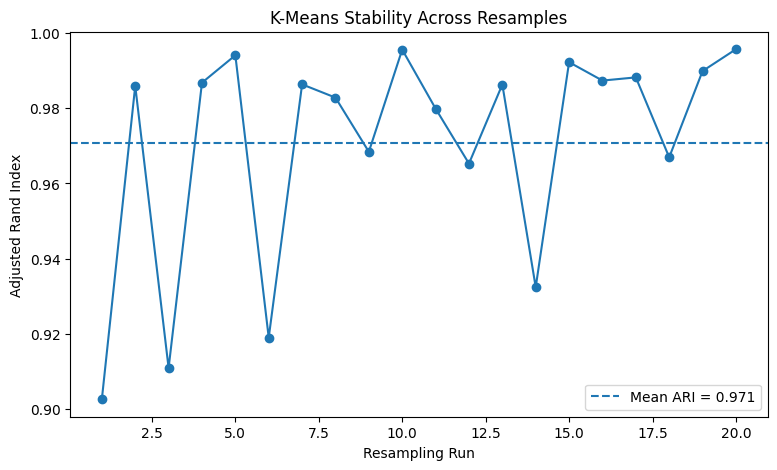

In [27]:
plt.figure(figsize=(9, 5))

plt.plot(
    stability_df["Run"],
    stability_df["ARI"],
    marker="o"
)

plt.axhline(
    stability_df["ARI"].mean(),
    linestyle="--",
    label=f"Mean ARI = {stability_df['ARI'].mean():.3f}"
)

plt.xlabel("Resampling Run")
plt.ylabel("Adjusted Rand Index")
plt.title("K-Means Stability Across Resamples")
plt.legend()
plt.show()

## 11. Final Customer-Level Dataset

In [28]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log,Cluster,Segment
0,12346.0,326,12,77556.46,5.789960,2.564949,11.258774,3,Champions / High-Value
1,12347.0,2,8,4921.53,1.098612,2.197225,8.501578,3,Champions / High-Value
2,12348.0,75,5,1658.40,4.330733,1.791759,7.414211,1,At-Risk / Mid-Value
3,12349.0,19,3,3678.69,2.995732,1.386294,8.210584,2,Recent / Emerging
4,12350.0,310,1,294.40,5.739793,0.693147,5.688330,0,Inactive / Low-Value


## 12. SQLite Database

This section stores the final customer-level segmentation, transaction data, model-selection results, and stability results in SQLite. The tables are written with `replace` so rerunning the notebook does not create duplicate rows.

In [29]:
from pathlib import Path
import sqlite3

DB_DIR = Path("customer_segmentation_streamlit")
DB_DIR.mkdir(exist_ok=True)

DB_PATH = DB_DIR / "customer_segmentation.db"

conn = sqlite3.connect(DB_PATH)

print(f"Connected to: {DB_PATH}")

Connected to: customer_segmentation_streamlit\customer_segmentation.db


In [30]:
# Store transaction-level data.
df_sales.to_sql(
    "transactions",
    conn,
    if_exists="replace",
    index=False
)

# Add average order value before storing the customer table.
rfm["AOV"] = np.where(
    rfm["Frequency"] > 0,
    rfm["Monetary"] / rfm["Frequency"],
    np.nan
)

# Store the final customer-level segmentation once.
rfm.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

# Store model-selection results for every tested K.
model_results = validation_df.copy()
model_results["Selected"] = model_results["K"].eq(optimal_k)

model_results.to_sql(
    "model_results",
    conn,
    if_exists="replace",
    index=False
)

# Store stability results separately.
stability_df.to_sql(
    "stability_results",
    conn,
    if_exists="replace",
    index=False
)

# Store the final cluster profile for convenient dashboard use.
final_profile.reset_index().to_sql(
    "cluster_profiles",
    conn,
    if_exists="replace",
    index=False
)

# Helpful indexes for common dashboard queries.
conn.execute(
    'CREATE INDEX IF NOT EXISTS idx_customers_customer_id '
    'ON customers("Customer ID")'
)
conn.execute(
    'CREATE INDEX IF NOT EXISTS idx_customers_segment '
    'ON customers("Segment")'
)

conn.commit()

print("Database tables written successfully.")

Database tables written successfully.


In [31]:
tables = pd.read_sql(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name
    """,
    conn
)

tables

,name
0,cluster_profiles
1,customers
2,model_results
3,stability_results
4,transactions


## 13. SQL Business Analysis

These queries demonstrate how the database can be used for business analysis rather than only serving as storage.

### 13.1 Segment performance

Compare customer count, average RFM behavior, and total revenue by segment.

In [32]:
segment_summary = pd.read_sql(
    """
    SELECT
        Segment,
        COUNT(*) AS Customers,
        ROUND(AVG(Recency), 2) AS Avg_Recency,
        ROUND(AVG(Frequency), 2) AS Avg_Frequency,
        ROUND(AVG(Monetary), 2) AS Avg_Monetary,
        ROUND(SUM(Monetary), 2) AS Revenue,
        ROUND(SUM(Monetary) / COUNT(*), 2) AS Revenue_Per_Customer
    FROM customers
    GROUP BY Segment
    ORDER BY Revenue DESC
    """,
    conn
)

segment_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Revenue,Revenue_Per_Customer
0,Champions / High-Value,1186,28.02,19.19,10641.65,12620992.65,10641.65
1,At-Risk / Mid-Value,1451,227.58,5.08,1920.62,2786814.50,1920.62
2,Recent / Emerging,1248,28.27,3.03,841.09,1049681.39,841.09
3,Inactive / Low-Value,1968,392.95,1.38,317.38,624597.23,317.38


### 13.2 Revenue concentration

Calculate each segment's share of total revenue. This is useful for prioritizing retention effort.

In [33]:
segment_revenue = pd.read_sql(
    """
    WITH segment_totals AS (
        SELECT
            Segment,
            SUM(Monetary) AS Revenue
        FROM customers
        GROUP BY Segment
    )
    SELECT
        Segment,
        ROUND(Revenue, 2) AS Revenue,
        ROUND(
            100.0 * Revenue / SUM(Revenue) OVER (),
            2
        ) AS Revenue_Share_Pct
    FROM segment_totals
    ORDER BY Revenue DESC
    """,
    conn
)

segment_revenue

,Segment,Revenue,Revenue_Share_Pct
0,Champions / High-Value,12620992.65,73.88
1,At-Risk / Mid-Value,2786814.50,16.31
2,Recent / Emerging,1049681.39,6.14
3,Inactive / Low-Value,624597.23,3.66


### 13.3 Highest-value customers

Identify the customers contributing the most monetary value.

In [34]:
top_customers = pd.read_sql(
    """
    SELECT
        "Customer ID" AS Customer_ID,
        Segment,
        Recency,
        Frequency,
        Monetary,
        AOV
    FROM customers
    ORDER BY Monetary DESC
    LIMIT 10
    """,
    conn
)

top_customers

,Customer_ID,Segment,Recency,Frequency,Monetary,AOV
0,18102.0,Champions / High-Value,1,145,580987.04,4006.807172
1,14646.0,Champions / High-Value,2,145,526751.52,3632.769103
2,14156.0,Champions / High-Value,10,145,304719.88,2101.516414
3,14911.0,Champions / High-Value,1,375,279477.79,745.274107
4,17450.0,Champions / High-Value,8,51,244784.25,4799.691176
5,13694.0,Champions / High-Value,4,143,195640.69,1368.116713
6,17511.0,Champions / High-Value,3,60,172132.87,2868.881167
7,16446.0,Champions / High-Value,1,2,168472.50,84236.250000
8,16684.0,Champions / High-Value,4,55,147142.77,2675.323091
9,12415.0,Champions / High-Value,24,24,144033.37,6001.390417


### 13.4 At-risk customer opportunity

Find customers in the At-Risk segment and rank them by monetary value so retention activity can be prioritized.

In [35]:
at_risk_customers = pd.read_sql(
    """
    SELECT
        "Customer ID" AS Customer_ID,
        Recency,
        Frequency,
        Monetary,
        AOV
    FROM customers
    WHERE Segment = 'At-Risk / Mid-Value'
    ORDER BY Monetary DESC
    LIMIT 20
    """,
    conn
)

at_risk_customers

,Customer_ID,Recency,Frequency,Monetary,AOV
0,15749.0,235,3,44534.30,14844.766667
1,15098.0,182,3,39916.50,13305.500000
2,13902.0,632,5,34023.26,6804.652000
3,12357.0,33,2,17437.66,8718.830000
4,13687.0,438,1,11880.84,11880.840000
5,14134.0,383,15,11123.35,741.556667
6,15032.0,256,8,11010.05,1376.256250
7,18052.0,565,1,10877.18,10877.180000
8,14028.0,550,3,10396.50,3465.500000
9,12758.0,117,7,9903.24,1414.748571


## 14. Conclusion

The final K=4 K-Means solution provides four interpretable customer segments:

- **Inactive / Low-Value**
- **At-Risk / Mid-Value**
- **Recent / Emerging**
- **Champions / High-Value**

The model was evaluated using multiple internal clustering metrics and tested for stability using repeated 80% resampling and Adjusted Rand Index. The SQLite layer then makes the segmentation reusable for customer-level analysis and dashboard queries.

The main business value is not the cluster number itself; it is the ability to identify distinct customer behaviors and translate them into targeted retention, growth, and reactivation strategies.

In [36]:
conn.close()
print("SQLite connection closed.")

SQLite connection closed.


In [37]:
rfm.to_csv("customer_segments.csv", index=False)

print("Final customer segmentation dataset saved as customer_segments.csv")

Final customer segmentation dataset saved as customer_segments.csv


In [38]:
import sqlite3

DB_PATH = r"customer_segmentation_streamlit\customer_segmentation.db"

conn = sqlite3.connect(DB_PATH)

print("Database connected successfully.")

Database connected successfully.


In [39]:
df_sales.to_sql(
    "transactions",
    conn,
    if_exists="replace",
    index=False
)

print("Transactions saved.")

Transactions saved.


In [40]:
rfm["AOV"] = rfm["Monetary"] / rfm["Frequency"]

In [41]:
rfm.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("Customer segmentation saved.")

Customer segmentation saved.


In [42]:
model_results = pd.DataFrame({
    "K": [optimal_k],
    "Silhouette": [silhouette],
    "Calinski_Harabasz": [calinski],
    "Davies_Bouldin": [davies],
    "Mean_ARI": [stability_df["ARI"].mean()],
    "Min_ARI": [stability_df["ARI"].min()],
    "Max_ARI": [stability_df["ARI"].max()]
})

model_results

,K,Silhouette,Calinski_Harabasz,Davies_Bouldin,Mean_ARI,Min_ARI,Max_ARI
0,4,0.364958,5029.966474,0.93082,0.970808,0.902697,0.995622


In [43]:
# Save model validation results
model_results.to_sql(
    "model_results",
    conn,
    if_exists="replace",
    index=False
)

print("Model results saved successfully.")

Model results saved successfully.


In [44]:
pd.read_sql("SELECT * FROM model_results", conn)

,K,Silhouette,Calinski_Harabasz,Davies_Bouldin,Mean_ARI,Min_ARI,Max_ARI
0,4,0.364958,5029.966474,0.93082,0.970808,0.902697,0.995622


In [45]:
tables = pd.read_sql(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    """,
    conn
)

tables

,name
0,stability_results
1,cluster_profiles
2,transactions
3,customers
4,model_results


## 14. SQL Business Analysis

In [46]:
query = """
SELECT
    Segment,
    COUNT(*) AS Customers,
    SUM(Monetary) AS Revenue
FROM customers
GROUP BY Segment
ORDER BY Revenue DESC
"""

segment_summary = pd.read_sql(query, conn)

segment_summary

,Segment,Customers,Revenue
0,Champions / High-Value,1186,12620992.65
1,At-Risk / Mid-Value,1451,2786814.50
2,Recent / Emerging,1248,1049681.39
3,Inactive / Low-Value,1968,624597.23


In [47]:
query = """
SELECT
    Segment,
    COUNT(*) AS Customers,
    SUM(Monetary) AS Revenue
FROM customers
GROUP BY Segment
ORDER BY Revenue DESC
"""

segment_revenue = pd.read_sql(query, conn)

segment_revenue

,Segment,Customers,Revenue
0,Champions / High-Value,1186,12620992.65
1,At-Risk / Mid-Value,1451,2786814.50
2,Recent / Emerging,1248,1049681.39
3,Inactive / Low-Value,1968,624597.23
